<a href="https://colab.research.google.com/github/cs24dse009-ops/CSL701-CS34_Machine-Learning-Lab/blob/main/ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Ayush M Naik

Batch : CS2


Roll Number : CS34



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [1]:
# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset (Upload data.csv to Google Colab first)
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('data.csv')

# Display dataset information
print("Dataset loaded successfully!")
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Saving data.csv to data.csv
Dataset loaded successfully!

First 5 Rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.

# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

First 5 Rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_wor

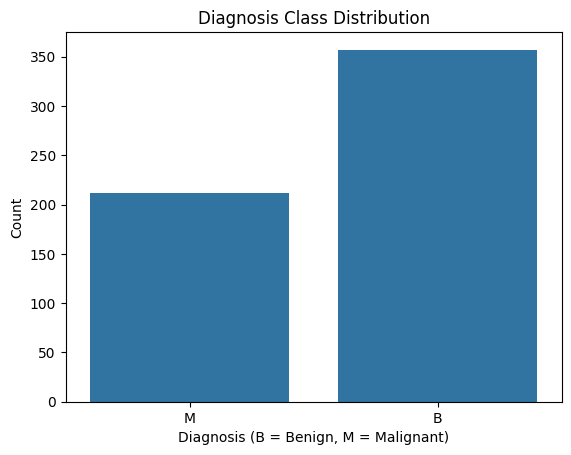

In [2]:
# Task 2: Explore the Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('data.csv')

# 1. Display first five rows
print("First 5 Rows:")
print(df.head())

# 2. Dataset shape
print("\nDataset Shape:", df.shape)

# 3. Check missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

# 4. Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# 5. Check column data types
print("\nColumn Data Types:")
print(df.dtypes)

# 6. Dataset information
print("\nDataset Information:")
df.info()

# 7. Inspect target class distribution
if 'diagnosis' in df.columns:
    print("\nDiagnosis Class Distribution:")
    print(df['diagnosis'].value_counts())

    print("\nDiagnosis Class Distribution (Percentage):")
    print(df['diagnosis'].value_counts(normalize=True) * 100)

    # 8. Visualize target class distribution
    sns.countplot(data=df, x='diagnosis')
    plt.title("Diagnosis Class Distribution")
    plt.xlabel("Diagnosis (B = Benign, M = Malignant)")
    plt.ylabel("Count")
    plt.show()
else:
    print("\nError: 'diagnosis' column not found.")
    print("Available columns:", df.columns.tolist())

# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [3]:
# Task 3: Data Cleaning and Feature/Target Selection

import pandas as pd

# Load dataset
df = pd.read_csv('data.csv')

# 1. Drop metadata columns if they exist
df.drop(columns=['id', 'Unnamed: 32'], inplace=True, errors='ignore')

# 2. Convert diagnosis into numerical values
# M = Malignant (1), B = Benign (0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# 3. Separate features (X) and target (y)
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# 4. Display results
print("Data cleaning completed successfully!")

print("\nFeature Matrix X Shape:", X.shape)
print("Target Vector y Shape:", y.shape)

print("\nNumber of Features:", X.shape[1])
print("\nFirst 5 Rows of X:")
print(X.head())

print("\nFirst 5 Values of y:")
print(y.head())

print("\nTarget Class Distribution:")
print(y.value_counts().rename(index={0: 'Benign', 1: 'Malignant'}))

# 5. Verify data types and missing values
print("\nFeature Data Types:")
print(X.dtypes)

print("\nMissing Values in X:", X.isnull().sum().sum())
print("Missing Values in y:", y.isnull().sum())

# Verify expected number of features
assert X.shape[1] == 30, "Error: Expected 30 features."
assert y.notnull().all(), "Error: Target contains missing values."

print("\nVerification successful: X contains 30 features.")

Data cleaning completed successfully!

Feature Matrix X Shape: (569, 30)
Target Vector y Shape: (569,)

Number of Features: 30

First 5 Rows of X:
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280  

# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [4]:
# Task 4: Standardize Features using StandardScaler

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('data.csv')

# Drop metadata columns
df.drop(columns=['id', 'Unnamed: 32'], inplace=True, errors='ignore')

# Convert diagnosis into numerical values
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Separate features (X) and target (y)
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert standardized features into a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display results
print("Standardization completed successfully!")
print("\nStandardized Feature Matrix Shape:", X_scaled.shape)

print("\nFirst 5 Rows of Standardized Data:")
print(X_scaled.head())

# Verify mean and standard deviation
print("\nMean of Each Feature (approximately 0):")
print(X_scaled.mean().round(2))

print("\nStandard Deviation of Each Feature (approximately 1):")
print(X_scaled.std(ddof=0).round(2))

print("\nTarget Vector Shape:", y.shape)

Standardization completed successfully!

Standardized Feature Matrix Shape: (569, 30)

First 5 Rows of Standardized Data:
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0     1.097064     -2.073335        1.269934   0.984375         1.568466   
1     1.829821     -0.353632        1.685955   1.908708        -0.826962   
2     1.579888      0.456187        1.566503   1.558884         0.942210   
3    -0.768909      0.253732       -0.592687  -0.764464         3.283553   
4     1.750297     -1.151816        1.776573   1.826229         0.280372   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0          3.283515        2.652874             2.532475       2.217515   
1         -0.487072       -0.023846             0.548144       0.001392   
2          1.052926        1.363478             2.037231       0.939685   
3          3.402909        1.915897             1.451707       2.867383   
4          0.539340        1.371011           

# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [5]:
# Task 5: Implement PCA (30D to 2D)

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv('data.csv')

# Drop metadata columns
df.drop(columns=['id', 'Unnamed: 32'], inplace=True, errors='ignore')

# Convert diagnosis into numerical values
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Separate features and target
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA: Reduce 30 features to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame for the reduced data
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['diagnosis'] = y.values

# Display results
print("PCA applied successfully!")
print("\nOriginal Feature Dimensions:", X.shape[1])
print("Reduced Feature Dimensions:", X_pca.shape[1])

print("\nFirst 5 Rows of PCA Transformed Data:")
print(pca_df.head())

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained by 2 Components:",
      round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

print("\nPCA Data Shape:", X_pca.shape)

PCA applied successfully!

Original Feature Dimensions: 30
Reduced Feature Dimensions: 2

First 5 Rows of PCA Transformed Data:
        PC1        PC2  diagnosis
0  9.192837   1.948583          1
1  2.387802  -3.768172          1
2  5.733896  -1.075174          1
3  7.122953  10.275589          1
4  3.935302  -1.948072          1

Explained Variance Ratio:
[0.44272026 0.18971182]

Total Variance Explained by 2 Components: 63.24 %

PCA Data Shape: (569, 2)


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


In [6]:
# Task 6: Analyze Explained Variance Ratio

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv('data.csv')

# Drop metadata columns
df.drop(columns=['id', 'Unnamed: 32'], inplace=True, errors='ignore')

# Convert diagnosis into numerical values
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Separate features and target
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Calculate explained variance
variance_pc1 = pca.explained_variance_ratio_[0]
variance_pc2 = pca.explained_variance_ratio_[1]
cumulative_variance = pca.explained_variance_ratio_.sum()

# Display results
print("Explained Variance Analysis")
print("---------------------------")
print(f"Variance explained by PC1: {variance_pc1 * 100:.2f}%")
print(f"Variance explained by PC2: {variance_pc2 * 100:.2f}%")
print(f"Cumulative variance retained: {cumulative_variance * 100:.2f}%")

print("\nInterpretation:")
print(f"PC1 retains {variance_pc1 * 100:.2f}% of the total variance.")
print(f"PC2 retains an additional {variance_pc2 * 100:.2f}% of the total variance.")
print(f"Together, PC1 and PC2 retain {cumulative_variance * 100:.2f}% of the total variance.")

Explained Variance Analysis
---------------------------
Variance explained by PC1: 44.27%
Variance explained by PC2: 18.97%
Cumulative variance retained: 63.24%

Interpretation:
PC1 retains 44.27% of the total variance.
PC2 retains an additional 18.97% of the total variance.
Together, PC1 and PC2 retain 63.24% of the total variance.


# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

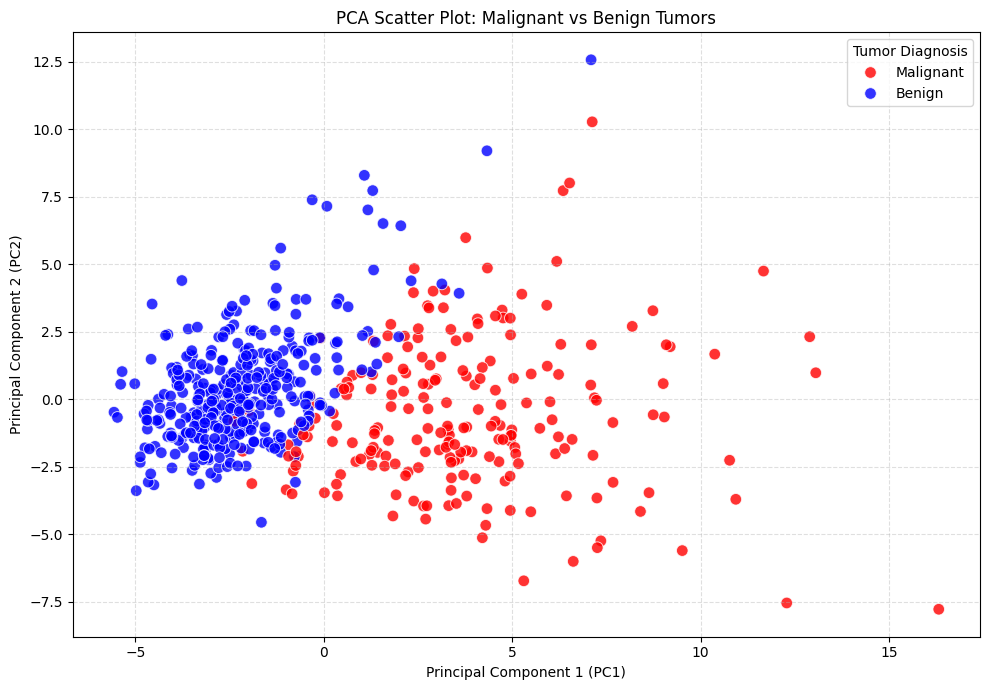

Variance explained by PC1: 44.27%
Variance explained by PC2: 18.97%
Total variance retained: 63.24%


In [7]:
# Task 7: Visualize PCA Transformed Scatter Plot

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv('data.csv')

# Drop metadata columns
df.drop(columns=['id', 'Unnamed: 32'], inplace=True, errors='ignore')

# Separate features and target
y = df['diagnosis']
X = df.drop(columns=['diagnosis'])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce 30 dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame for visualization
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Diagnosis'] = y.map({'M': 'Malignant', 'B': 'Benign'})

# Plot 2D scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Diagnosis',
    palette={'Malignant': 'red', 'Benign': 'blue'},
    s=70,
    alpha=0.8
)

plt.title('PCA Scatter Plot: Malignant vs Benign Tumors')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Tumor Diagnosis')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Display explained variance
print("Variance explained by PC1: {:.2f}%".format(
    pca.explained_variance_ratio_[0] * 100
))
print("Variance explained by PC2: {:.2f}%".format(
    pca.explained_variance_ratio_[1] * 100
))
print("Total variance retained: {:.2f}%".format(
    pca.explained_variance_ratio_.sum() * 100
))

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [8]:
# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# 1. Load dataset
df = pd.read_csv('data.csv')

# 2. Drop metadata columns
df.drop(columns=['id', 'Unnamed: 32'], inplace=True, errors='ignore')

# 3. Separate features and target
X = df.drop(columns=['diagnosis'])
y = df['diagnosis'].map({'M': 1, 'B': 0})

# 4. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Standardize features (fit only on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train Logistic Regression model
model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled, y_train)

# 7. Make predictions
y_pred = model.predict(X_test_scaled)

# 8. Evaluate baseline performance
print("Logistic Regression: Original 30 Features")
print("------------------------------------------")
print(f"Accuracy  : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['Benign', 'Malignant']
))

Logistic Regression: Original 30 Features
------------------------------------------
Accuracy  : 96.49%
Precision : 0.9750
Recall    : 0.9286
F1-Score  : 0.9512

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [9]:
# Task 9: Train Classifier on PCA Transformed Data (2 Features)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# 1. Load dataset
df = pd.read_csv('data.csv')

# 2. Drop metadata columns
df.drop(columns=['id', 'Unnamed: 32'], inplace=True, errors='ignore')

# 3. Separate features and target
X = df.drop(columns=['diagnosis'])
y = df['diagnosis'].map({'M': 1, 'B': 0})

# 4. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Apply PCA to reduce 30 features to 2 components
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 7. Train Logistic Regression using PC1 and PC2
model_pca = LogisticRegression(max_iter=5000)
model_pca.fit(X_train_pca, y_train)

# 8. Make predictions
y_pred_pca = model_pca.predict(X_test_pca)

# 9. Evaluate model performance
print("Logistic Regression: PCA Transformed Data (2 Features)")
print("------------------------------------------------------")
print("Training data shape:", X_train_pca.shape)
print("Testing data shape:", X_test_pca.shape)

print(f"\nAccuracy  : {accuracy_score(y_test, y_pred_pca) * 100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred_pca):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_pca):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_pca):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_pca))

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred_pca,
    target_names=['Benign', 'Malignant']
))

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print(f"Total Variance Retained: "
      f"{pca.explained_variance_ratio_.sum() * 100:.2f}%")

Logistic Regression: PCA Transformed Data (2 Features)
------------------------------------------------------
Training data shape: (455, 2)
Testing data shape: (114, 2)

Accuracy  : 94.74%
Precision : 0.9737
Recall    : 0.8810
F1-Score  : 0.9250

Confusion Matrix:
[[71  1]
 [ 5 37]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.93      0.99      0.96        72
   Malignant       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114


Explained Variance Ratio:
[0.44593522 0.18545255]
Total Variance Retained: 63.14%


# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



ACCURACY COMPARISON
Before PCA: 96.49 %
After PCA: 94.74 %

CONFUSION MATRIX - BEFORE PCA
[[71  1]
 [ 3 39]]

CONFUSION MATRIX - AFTER PCA
[[71  1]
 [ 5 37]]

CLASSIFICATION REPORT - BEFORE PCA
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


CLASSIFICATION REPORT - AFTER PCA
              precision    recall  f1-score   support

      Benign       0.93      0.99      0.96        72
   Malignant       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



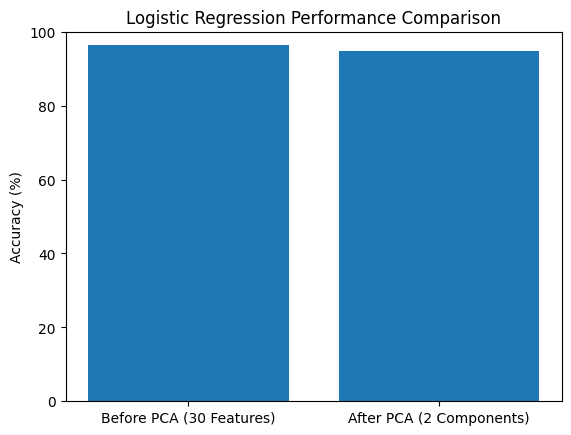

Variance retained by 2 components: 63.14 %


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv('data.csv')

# Remove unnecessary columns
df.drop(columns=['id', 'Unnamed: 32'], inplace=True, errors='ignore')

# Separate features and target
X = df.drop(columns=['diagnosis'])
y = df['diagnosis'].map({'M': 1, 'B': 0})

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model BEFORE PCA (30 features)
model_original = LogisticRegression(max_iter=5000)
model_original.fit(X_train_scaled, y_train)
y_pred_original = model_original.predict(X_test_scaled)

# Apply PCA (2 components)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Model AFTER PCA (2 features)
model_pca = LogisticRegression(max_iter=5000)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)

# Compare accuracy
print("ACCURACY COMPARISON")
print("Before PCA:", round(accuracy_score(y_test, y_pred_original) * 100, 2), "%")
print("After PCA:", round(accuracy_score(y_test, y_pred_pca) * 100, 2), "%")

# Confusion matrices
print("\nCONFUSION MATRIX - BEFORE PCA")
print(confusion_matrix(y_test, y_pred_original))

print("\nCONFUSION MATRIX - AFTER PCA")
print(confusion_matrix(y_test, y_pred_pca))

# Classification reports
print("\nCLASSIFICATION REPORT - BEFORE PCA")
print(classification_report(
    y_test, y_pred_original,
    target_names=['Benign', 'Malignant'],
    zero_division=0
))

print("\nCLASSIFICATION REPORT - AFTER PCA")
print(classification_report(
    y_test, y_pred_pca,
    target_names=['Benign', 'Malignant'],
    zero_division=0
))

# Plot accuracy comparison
accuracies = [
    accuracy_score(y_test, y_pred_original) * 100,
    accuracy_score(y_test, y_pred_pca) * 100
]

plt.bar(['Before PCA (30 Features)', 'After PCA (2 Components)'], accuracies)
plt.ylabel('Accuracy (%)')
plt.title('Logistic Regression Performance Comparison')
plt.ylim(0, 100)
plt.show()

print("Variance retained by 2 components:",
      round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.